# Gomi - Full Training Pipeline

**Step 1:** Fine-tune DistilBERT
**Step 2:** Train Logistic Regression risk fusion model
**Step 3:** Push both models to Hugging Face

> Make sure **Runtime → Change runtime type → T4 GPU** is selected before running.

---
**Hugging Face repos:**
- Dataset: `GitRatBCSAD/gomi-datasets`
- Sentiment model: `GitRatBCSAD/gomi-sentiment`
- Risk model: `GitRatBCSAD/gomi-risk`

In [1]:
import torch
import torchvision.io

class _VideoReaderStub:
    pass

torchvision.io.VideoReader = _VideoReaderStub

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING: No GPU detected. Go to Runtime → Change runtime type → T4 GPU')

CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q transformers==4.44.2 datasets scikit-learn imbalanced-learn huggingface_hub joblib shap lizard nlpaug nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [3]:
from google.colab import userdata
from huggingface_hub import login
import os

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN, add_to_git_credential=False)
print('Logged in to Hugging Face.')

Logged in to Hugging Face.


In [4]:
HF_DATASET_REPO = 'GitRatBCSAD/gomi-datasets'
HF_SENTIMENT_REPO = 'GitRatBCSAD/gomi-sentiment'
HF_RISK_REPO = 'GitRatBCSAD/gomi-risk'

BASE_MODEL = 'distilbert-base-uncased'

# 3-class: frustration+caution merged into 'caution' since both are risk-positive
LABELS = ['caution', 'neutral', 'satisfaction']
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}
VALID_EMOTIONS = set(LABELS)  # for trained-model output validation
RAW_EMOTIONS = {'frustration', 'caution', 'neutral', 'satisfaction'}  # dataset raw labels
EMOTION_TO_LABEL = {  # map openreview 4-label dataset → 3-class training target
    'frustration': 'caution',
    'caution': 'caution',
    'neutral': 'neutral',
    'satisfaction':'satisfaction',
}

# Training hyperparameters
MAX_LENGTH = 128
BATCH_SIZE = 32 # good enough for T4 with DistilBERT
NUM_EPOCHS = 5
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
TEST_SIZE = 0.15
RANDOM_SEED = 42

os.makedirs('models/distilbert_sentiment', exist_ok=True)
os.makedirs('models/risk', exist_ok=True)

print('Config done.')

Config done.


In [5]:
from huggingface_hub import HfApi

hf_api = HfApi()

## Step 1 - Fine-tune DistilBERT

NOTE: Skip this if DistilBERT is already trained.

In [6]:
# raise SystemExit("SKIP - DistilBERT already on HF.")

### DistilBERT Training Baselines

Target: macro F1 ≥ 0.70 on 3-class imbalanced commit-message data.

| Reference | Result |
|-----------|--------|
| Biswas et al. 2021 (arXiv:2106.02581) | BERT/DistilBERT +6–12% F1 over SentiCR |
| Lin et al. 2024 (arXiv:2310.11113) | macro F1 0.65–0.94 on balanced SE datasets |
| Obaido et al. 2024 (PMC11132486) | fuzzy BERT ensemble max macro F1 0.883 |

Training uses class-weighted cross-entropy only. Instance-level intensity weighting removed.


### Training Datasets

Six sources combined into single pool. All pass through `EMOTION_TO_LABEL` before training (`frustration` → `caution`; others map directly).

| # | File | Rows | Source | Label mapping |
|---|------|------|--------|---------------|
| 1 | `openreview_labeled_2k.csv` | 2,000 | GitHub commit messages, human-labeled (primary taxonomy) | Native 4-class; frustration → caution |
| 2 | `senticr_labeled.csv` | 1,600 | Code review comments, 20 OSS projects on Gerrit — Ahmed et al., ASE'17 | negative → caution, non-negative → neutral |
| 3 | `StackOverflow.csv` | 1,500 | SO posts, Java-tagged threads — Lin et al., ICSE'18 | +1 → satisfaction, 0 → neutral, -1 → caution |
| 4 | `github.csv` | 7,122 | GitHub PR + commit comments, triple-rater — Novielli et al., MSR'20 | +1 → satisfaction, 0 → neutral, -1 → caution |
| 5 | `premo_labeled.csv` | 1,742 | PR messages, 36 OSS projects, validated by SE + neuroscience — Coutinho et al., EASE'24 | positive → satisfaction, negative → caution, undefined → skipped |
| 6 | `jira_labeled.csv` | 859 | Jira issue comments, Apache/Spring/JBoss/CodeHaus — Ortu et al., MSR'16 | anger/sadness (exclusive) → caution; joy/love (exclusive) → satisfaction; neutral rows excluded |

**Combined pool:** 14,823 samples — caution 4,435 (29.9%), neutral 6,914 (46.6%), satisfaction 3,474 (23.4%).

No class cap applied. Class imbalance handled solely by class-weighted cross-entropy loss.

In [7]:
import csv
import random
from collections import Counter
from huggingface_hub import hf_hub_download

def load_labeled_csv(filename, so_mapping=False):
    path = hf_hub_download(HF_DATASET_REPO, f'sentiment/{filename}', repo_type='dataset', token=HF_TOKEN)
    messages, label_ids = [], []
    skipped = 0

    with open(path, newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            if so_mapping:
                msg = row.get('text', '').strip()
                oracle = row.get('oracle', '').strip()

                if oracle == '1':    emotion = 'satisfaction'
                elif oracle == '0':  emotion = 'neutral'
                elif oracle == '-1': emotion = 'caution'
                else: continue
            else:
                msg = row.get('message', '').strip()
                raw = row.get('reconciled_emotion', '').strip().lower()
                if raw not in RAW_EMOTIONS:
                    skipped += 1; continue
                emotion = EMOTION_TO_LABEL[raw]

            if not msg or emotion not in VALID_EMOTIONS:
                skipped += 1; continue

            messages.append(msg)
            label_ids.append(LABEL2ID[emotion])

    print(f'  {filename}: Loaded {len(messages)} rows (skipped {skipped})')
    return messages, label_ids

print('[1/6] Loading datasets...')
msgs_2k,    ids_2k    = load_labeled_csv('openreview_labeled_2k.csv')
msgs_scr,   ids_scr   = load_labeled_csv('senticr_labeled.csv')
msgs_so,    ids_so    = load_labeled_csv('StackOverflow.csv', so_mapping=True)
msgs_gh,    ids_gh    = load_labeled_csv('github.csv', so_mapping=True)
msgs_premo, ids_premo = load_labeled_csv('premo_labeled.csv')
msgs_jira,  ids_jira  = load_labeled_csv('jira_labeled.csv')

messages = msgs_2k + msgs_scr + msgs_so + msgs_gh + msgs_premo + msgs_jira
label_ids = ids_2k + ids_scr + ids_so + ids_gh + ids_premo + ids_jira


print(f'\nPre-split pool: {len(messages)} samples.')
dist = Counter(LABELS[i] for i in label_ids)
for lbl, cnt in sorted(dist.items()):
    print(f'    {lbl:<14} {cnt:>5}  ({100*cnt/len(label_ids):.1f}%)')


[1/6] Loading datasets...


sentiment/openreview_labeled_2k.csv:   0%|          | 0.00/858k [00:00<?, ?B/s]

  openreview_labeled_2k.csv: Loaded 2000 rows (skipped 0)


sentiment/senticr_labeled.csv:   0%|          | 0.00/299k [00:00<?, ?B/s]

  senticr_labeled.csv: Loaded 1600 rows (skipped 0)


...

  github.csv: Loaded 7122 rows (skipped 0)


sentiment/premo_labeled.csv:   0%|          | 0.00/727k [00:00<?, ?B/s]

  premo_labeled.csv: Loaded 1742 rows (skipped 0)


sentiment/jira_labeled.csv:   0%|          | 0.00/60.1k [00:00<?, ?B/s]

  jira_labeled.csv: Loaded 859 rows (skipped 0)

Pre-split pool: 14823 samples.
    caution         4435  (29.9%)
    neutral         6914  (46.6%)
    satisfaction    3474  (23.4%)


In [8]:
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from datasets import Dataset

train_msgs, val_msgs, train_labels, val_labels = train_test_split(
    messages, label_ids,
    test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=label_ids
)
print(f'Split: {len(train_msgs)} train | {len(val_msgs)} val')

dist = Counter(LABELS[i] for i in train_labels)
for lbl, cnt in sorted(dist.items()):
    print(f'  {lbl:<14} {cnt:>5}  ({100*cnt/len(train_labels):.1f}%)')

print(f'\nLoading tokenizer ({BASE_MODEL})...')
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

train_ds = (
    Dataset.from_dict({'text': train_msgs, 'label': train_labels})
    .map(tokenize, batched=True).remove_columns(['text'])
)
val_ds = (
    Dataset.from_dict({'text': val_msgs, 'label': val_labels})
    .map(tokenize, batched=True).remove_columns(['text'])
)
train_ds.set_format('torch')
val_ds.set_format('torch')
collator = DataCollatorWithPadding(tokenizer=tokenizer)
print('Tokenization done.')


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Split: 12599 train | 2224 val
  caution         3769  (29.9%)
  neutral         5877  (46.6%)
  satisfaction    2953  (23.4%)

Loading tokenizer (distilbert-base-uncased)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/12599 [00:00<?, ? examples/s]

Map:   0%|          | 0/2224 [00:00<?, ? examples/s]

Tokenization done.


In [9]:
import numpy as np
import torch.nn as nn
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

print(f'[3/4] Loading {BASE_MODEL} and attaching classification head...')
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL, num_labels=len(LABELS), id2label=ID2LABEL, label2id=LABEL2ID
)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(model.device)
print(f'Class weights (label balance): {class_weights}')

class ClassWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor.to(logits.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    report = classification_report(labels, preds, target_names=LABELS, output_dict=True, zero_division=0)
    return {'accuracy': report['accuracy'], 'f1_macro': report['macro avg']['f1-score'],
            'precision': report['macro avg']['precision'], 'recall': report['macro avg']['recall']}

args = TrainingArguments(
    output_dir='models/distilbert_sentiment/checkpoints',
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=20,
    report_to='none',
    seed=RANDOM_SEED,
    fp16=torch.cuda.is_available(),
)

trainer = ClassWeightedTrainer(
    model=model, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    tokenizer=tokenizer, data_collator=collator,
    compute_metrics=compute_metrics,
)

print(f'[4/4] Fine-tuning for {NUM_EPOCHS} epochs on {len(train_msgs)} samples...')
trainer.train()


[3/4] Loading distilbert-base-uncased and attaching classification head...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Class weights (label balance): [1.1142655  0.71459361 1.42216955]
[4/4] Fine-tuning for 5 epochs on 12599 samples...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.504600,0.470419,0.808004,0.804634,0.806707,0.807571
2,0.314400,0.455081,0.832734,0.826973,0.826716,0.827679
3,0.295600,0.478207,0.825090,0.822299,0.820485,0.825397
4,0.239100,0.506005,0.824640,0.820961,0.819104,0.822967
5,0.148200,0.544788,0.824640,0.820771,0.819100,0.822609


TrainOutput(global_step=1970, training_loss=0.3228447850585589, metrics={'train_runtime': 283.5837, 'train_samples_per_second': 222.139, 'train_steps_per_second': 6.947, 'total_flos': 1993249984617954.0, 'train_loss': 0.3228447850585589, 'epoch': 5.0})

Final evaluation on validation set:


              precision    recall  f1-score   support

     caution       0.84      0.80      0.82       666
     neutral       0.85      0.86      0.85      1037
satisfaction       0.79      0.82      0.81       521

    accuracy                           0.83      2224
   macro avg       0.83      0.83      0.83      2224
weighted avg       0.83      0.83      0.83      2224



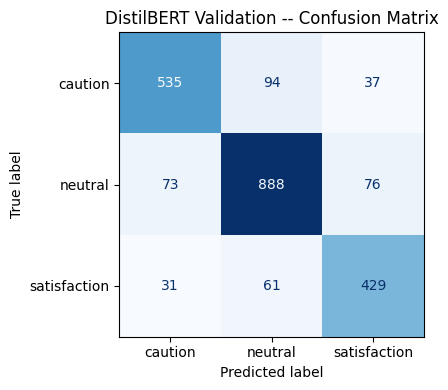

Confusion matrix saved.
Model saved to: models/distilbert_sentiment


In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print('Final evaluation on validation set:')
preds_out = trainer.predict(val_ds)
preds = np.argmax(preds_out.predictions, axis=-1)

print(classification_report(val_labels, preds, target_names=LABELS, zero_division=0))

cm = confusion_matrix(val_labels, preds, labels=list(range(len(LABELS))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('DistilBERT Validation -- Confusion Matrix')
plt.tight_layout()
plt.savefig('models/distilbert_sentiment/confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved.')

SENTIMENT_MODEL_DIR = 'models/distilbert_sentiment'
model.save_pretrained(SENTIMENT_MODEL_DIR)
tokenizer.save_pretrained(SENTIMENT_MODEL_DIR)
print(f'Model saved to: {SENTIMENT_MODEL_DIR}')


In [11]:
# ── Caution F1-optimal threshold ──────────────────────────────────────────────
# Binarized: Caution=1 vs Neutral+Satisfaction=0
# Sweeps p(caution) decision boundary 0.01→0.99 and selects the threshold
# that maximises Caution-class F1 on the DistilBERT validation set.
# Stored as distilbert_caution_threshold.json; backend loads it at startup
# so the Sentiment Trajectory chart reference line is model-derived, not hardcoded.
import json
from scipy.special import softmax as scipy_softmax
from sklearn.metrics import f1_score

# preds_out.predictions contains logits → convert to probabilities
probs = scipy_softmax(preds_out.predictions, axis=-1)
caution_probs = probs[:, LABEL2ID['caution']]
binary_labels = (np.array(val_labels) == LABEL2ID['caution']).astype(int)

best_threshold, best_f1 = 0.5, 0.0
for t in np.round(np.arange(0.01, 1.00, 0.01), 2):
    preds_bin = (caution_probs >= t).astype(int)
    f1 = f1_score(binary_labels, preds_bin, zero_division=0)
    if f1 > best_f1:
        best_f1, best_threshold = f1, float(t)

caution_threshold_artifact = {
    'threshold': round(best_threshold, 2),
    'caution_f1_at_threshold': round(best_f1, 4),
}
CAUTION_THRESHOLD_PATH = 'models/distilbert_caution_threshold.json'
with open(CAUTION_THRESHOLD_PATH, 'w') as fh:
    json.dump(caution_threshold_artifact, fh)

print(f"F1-optimal caution threshold : {best_threshold:.2f}")
print(f"Caution F1 at threshold      : {best_f1:.4f}")
print(f"Saved -> {CAUTION_THRESHOLD_PATH}")

F1-optimal caution threshold : 0.30
Caution F1 at threshold      : 0.8212
Saved -> models/distilbert_caution_threshold.json


In [12]:
hf_api.create_repo(repo_id=HF_SENTIMENT_REPO, repo_type='model', exist_ok=True, token=HF_TOKEN)
hf_api.upload_folder(
    repo_id=HF_SENTIMENT_REPO, repo_type='model',
    folder_path=SENTIMENT_MODEL_DIR, path_in_repo='.', token=HF_TOKEN,
)
print(f'Uploaded to: https://huggingface.co/{HF_SENTIMENT_REPO}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...kpoint-1182/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

  ...nt-1182/model.safetensors:   2%|2         | 5.44MB /  268MB            

  ...ckpoint-1970/scheduler.pt: 100%|##########| 1.47kB / 1.47kB            

...

  ...ckpoint-394/rng_state.pth: 100%|##########| 14.6kB / 14.6kB            

  ...ckpoint-788/rng_state.pth: 100%|##########| 14.6kB / 14.6kB            

  ...ckpoint-1576/scheduler.pt: 100%|##########| 1.47kB / 1.47kB            

  ...nt-1576/model.safetensors:   2%|2         | 5.64MB /  268MB            

Uploaded to: https://huggingface.co/GitRatBCSAD/gomi-sentiment


---
## Step 2 — Train Logistic Regression Risk Model
Uses the fine-tuned DistilBERT above to generate sentiment features for DeepJIT commits.

### JIT Training Sources

All sources loaded from `GitRatBCSAD/gomi-datasets/jit/`. Each contributes a `_commits.csv` (Kamei process metrics + bug labels) paired with a `_lizard.csv` (Lizard complexity per commit hash).

| Source | Projects | Commits | Notes |
|--------|----------|---------|-------|
| **DeepJIT** — Zeng et al., ISSTA'21 | 6: qt, openstack, go, jdt, gerrit, platform | 94,918 | Bug labels from `_raw.pkl` SZZ derivation. Full population used. |
| **geocabral / ORB** — Cabral et al., ICSE'19 | 14: npm, wagtail, brackets, broadleaf, camel, fabric8, jgroups, matplotlib, neutron, nova, sentry, spring-integration, tomcat, zulip | 264,893 | No native commit hash — recovered via `author_date_unix_timestamp` (~78–89% match rate per project). |
| **JIT-Fine** — Ni et al., ESEC/FSE'22 | 21: ant-ivy, opennlp, giraph, gora, parquet-mr + 16 Apache Commons | 27,319 | Kamei features and commit hashes pre-packaged upstream. |
| **PROMISE 2021** — Trautsch & Herbold, MSR'22 | 33 usable of 39 | 64,097 | No message column — recovered via `git log`. Labels collapsed from sparse per-bug matrix. |
| **ApacheJIT train** — Keshavarz & Nagappan, MSR'22 | 15 Apache projects | 44,834 | Fixed upstream train/test partition. Rebalanced before combining (see below). |
| **ApacheJIT test** | — | 27,586 | **Reserved exclusively for cross-ecosystem secondary validation. Never mixed into training.** |

**Split strategy:** DeepJIT, geocabral, JIT-Fine, PROMISE split **per-project by timestamp** (McIntosh & Kamei 2018): oldest 80% → training, newest 20% → primary validation. Prevents short-file-window inflation from random splits.

**Apache rebalancing:** ApacheJIT file-level buggy rate (~14.5%) is lower than primary pool (~37.4%). All Apache buggy records kept; clean records downsampled to match combined pool's buggy ratio before combining.

**Total training set:** 402,768 records — combined buggy rate 20.7%.

In [13]:
import csv
import re
from huggingface_hub import hf_hub_download
from transformers import pipeline as hf_pipeline

CONVENTIONAL_COMMIT_RE = r'^[a-z]+(\([^)]+\))?!?:\s*'
LOW_INFO_TOKEN_THRESHOLD = 5

def strip_prefix(msg):
    return re.sub(CONVENTIONAL_COMMIT_RE, '', msg or '', flags=re.IGNORECASE).strip()

def is_low_info(msg):
    return len(strip_prefix(msg).split()) < LOW_INFO_TOKEN_THRESHOLD


device = 0 if torch.cuda.is_available() else -1
sentiment_clf = hf_pipeline(
    'text-classification',
    model=HF_SENTIMENT_REPO,
    tokenizer=HF_SENTIMENT_REPO,
    top_k=None, truncation=True, max_length=128,
    device=device,
)
print(f'Sentiment classifier loaded (device={"GPU" if device==0 else "CPU"}).')

def norm_label(lbl):
    return lbl.lower().replace('label_', '')

def classify_batch(messages):
    """Returns (labels, risk_scores). risk_score = p(caution) from 3-class model."""
    cleaned = [strip_prefix(m)[:512] or 'empty' for m in messages]
    results = sentiment_clf(cleaned, batch_size=64)
    labels, scores = [], []
    for r in results:
        best = max(r, key=lambda x: x['score'])
        label = norm_label(best['label'])
        if label not in VALID_EMOTIONS:
            label = next((k for k in VALID_EMOTIONS if k in label), 'neutral')
        risk_score = min(sum(x['score'] for x in r if norm_label(x['label']) == 'caution'), 1.0)
        labels.append(label)
        scores.append(risk_score)
    return labels, scores


config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Sentiment classifier loaded (device=GPU).


In [14]:
import bisect
import csv
import datetime
from huggingface_hub import hf_hub_download

def percentile_rank(value, sorted_values):
    if not sorted_values or len(sorted_values) == 1: return 0.0
    return round(bisect.bisect_right(sorted_values, value) / len(sorted_values), 4)

def download_csv(relpath):
    path = hf_hub_download(HF_DATASET_REPO, relpath, repo_type='dataset', token=HF_TOKEN)
    with open(path, newline='', encoding='utf-8') as f:
        return list(csv.DictReader(f))

def to_bool(v):
    return str(v).strip().lower() in ('1', 'true', 'yes')

def score_sentiment(commits):
    """Returns (sentiment_score per commit, low_info flag per commit)."""
    messages = [r.get('message', '') for r in commits]
    low_info = [is_low_info(m) for m in messages]
    non_low_msgs = [m for m, li in zip(messages, low_info) if not li]
    _, non_low_scores = classify_batch(non_low_msgs)
    mean_score = sum(non_low_scores) / len(non_low_scores) if non_low_scores else 0.5
    scores = iter(non_low_scores)
    sentiment = [mean_score if li else next(scores) for li in low_info]
    return sentiment, low_info

def load_lizard(subdir, name):
    lizard = {}
    for row in download_csv(f'jit/{subdir}/{subdir}_{name}_lizard.csv'):
        if row.get('avg_ccn'):
            lizard[row['commit_hash']] = {
                'avg_ccn':    float(row['avg_ccn']),
                'avg_nloc':   float(row['avg_nloc']),
                'func_count': float(row['func_count']),
                'avg_params': float(row['avg_params']),
                'project':    row.get('project', 'unknown'),
            }
    return lizard

JIT_SOURCES = {
    'deepjit':   ['qt', 'openstack', 'go', 'jdt', 'gerrit', 'platform'],
    'promise':   ['archiva', 'calcite', 'cayenne', 'commons-jexl', 'deltaspike', 'derby',
                  'directory-fortress-core', 'eagle', 'falcon', 'flume', 'helix',
                  'httpcomponents-client', 'httpcomponents-core', 'jena', 'jspwiki', 'knox',
                  'kylin', 'lens', 'mahout', 'manifoldcf', 'mina-sshd', 'nifi', 'nutch',
                  'oozie', 'phoenix', 'ranger', 'roller', 'samza', 'storm', 'streams',
                  'systemml', 'tez', 'tika'],
    'geocabral': ['brackets', 'broadleaf', 'camel', 'fabric', 'jgroups', 'matplotlib',
                  'neutron', 'nova', 'npm', 'sentry', 'spring-integration', 'tomcat',
                  'wagtail', 'zulip'],
    'jitfine':   ['ant-ivy', 'commons-bcel', 'commons-beanutils', 'commons-codec',
                  'commons-collections', 'commons-compress', 'commons-configuration',
                  'commons-dbcp', 'commons-digester', 'commons-io', 'commons-jcs',
                  'commons-lang', 'commons-math', 'commons-net', 'commons-scxml',
                  'commons-validator', 'commons-vfs', 'giraph', 'gora', 'opennlp',
                  'parquet-mr'],
}
deepjit_records = []

for subdir, projects in JIT_SOURCES.items():
  for proj in projects:
    print(f"Loading {subdir} ({proj})...")
    try:
        commits = download_csv(f'jit/{subdir}/{subdir}_{proj}_commits.csv')
        lizard = load_lizard(subdir, proj)
        print(f"  Lizard: {len(lizard)}/{len(commits)} commits have complexity data")

        all_ent = sorted(float(r['entrophy']) for r in commits)
        all_ndev = sorted(float(r['ndev']) for r in commits)
        all_age = sorted(float(r['age']) for r in commits)
        all_ccn = sorted(v['avg_ccn'] for v in lizard.values())
        all_nloc = sorted(v['avg_nloc'] for v in lizard.values())
        all_fcnt = sorted(v['func_count'] for v in lizard.values())
        all_param = sorted(v['avg_params'] for v in lizard.values())

        sentiment_scores, low_info_flags = score_sentiment(commits)

        for row, sent_score, li in zip(commits, sentiment_scores, low_info_flags):
            liz = lizard.get(row['commit_hash'])
            deepjit_records.append({
                'commit_hash':      row['commit_hash'],
                'project':          proj,
                'author_date':      int(float(row['author_date_unix_timestamp'])) if row.get('author_date_unix_timestamp') else None,
                'sentiment_score':  sent_score,
                'change_entropy':   percentile_rank(float(row['entrophy']), all_ent),
                'fix_ratio':        1.0 if to_bool(row.get('fix')) else 0.0,
                'ndev_score':       percentile_rank(float(row['ndev']), all_ndev),
                'age_score':        percentile_rank(float(row['age']), all_age),
                'low_info_ratio':   1.0 if li else 0.0,
                'avg_ccn_score':    percentile_rank(liz['avg_ccn'],    all_ccn)   if liz and all_ccn   else None,
                'avg_nloc_score':   percentile_rank(liz['avg_nloc'],   all_nloc)  if liz and all_nloc  else None,
                'func_count_score': percentile_rank(liz['func_count'], all_fcnt)  if liz and all_fcnt  else None,
                'avg_params_score': percentile_rank(liz['avg_params'], all_param) if liz and all_param else None,
                'buggy':            1 if to_bool(row.get('buggy')) else 0,
            })

        print(f"  \u2192 {sum(1 for r in deepjit_records if r['project'] == proj)} records added")

    except Exception as e:
        import traceback; traceback.print_exc()
        print(f"  [skip] {proj} failed: {e}")
        continue

if not deepjit_records:
    raise RuntimeError(
        "All JIT projects failed to load \u2014 see [skip] / tracebacks above for root cause."
    )

for feat in ['avg_ccn_score', 'avg_nloc_score', 'func_count_score', 'avg_params_score']:
    vals = [r[feat] for r in deepjit_records if r[feat] is not None]
    mean_val = sum(vals) / len(vals) if vals else 0.5
    for r in deepjit_records:
        if r[feat] is None:
            r[feat] = mean_val

print(f"\nTotal JIT commits loaded: {len(deepjit_records)}")
buggy_rate = sum(r['buggy'] for r in deepjit_records) / len(deepjit_records)
mean_sent = sum(r['sentiment_score'] for r in deepjit_records) / len(deepjit_records)
mean_ccn = sum(r['avg_ccn_score']   for r in deepjit_records) / len(deepjit_records)
dated = sum(1 for r in deepjit_records if r['author_date'] is not None)
print(f"Buggy rate: {buggy_rate:.2%}   Mean sentiment: {mean_sent:.3f}   Mean CCN score: {mean_ccn:.3f}")
print(f"Commits with timestamps: {dated}/{len(deepjit_records)} ({100*dated/len(deepjit_records):.0f}%)")


Loading deepjit (qt)...


jit/deepjit/deepjit_qt_commits.csv:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

jit/deepjit/deepjit_qt_lizard.csv:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

  Lizard: 3723/23912 commits have complexity data
  → 23912 records added
Loading deepjit (openstack)...


jit/deepjit/deepjit_openstack_commits.cs(…):   0%|          | 0.00/13.7M [00:00<?, ?B/s]

...

jit/jitfine/jitfine_opennlp_lizard.csv:   0%|          | 0.00/81.9k [00:00<?, ?B/s]

  Lizard: 1068/1086 commits have complexity data
  → 1086 records added
Loading jitfine (parquet-mr)...


jit/jitfine/jitfine_parquet-mr_commits.c(…):   0%|          | 0.00/422k [00:00<?, ?B/s]

jit/jitfine/jitfine_parquet-mr_lizard.cs(…):   0%|          | 0.00/89.5k [00:00<?, ?B/s]

  Lizard: 1115/1120 commits have complexity data
  → 1120 records added

Total JIT commits loaded: 451227
Buggy rate: 21.83%   Mean sentiment: 0.152   Mean CCN score: 0.503
Commits with timestamps: 451227/451227 (100%)


### Temporal Split (per-project)

Random 80/20 stratified splits on DeepJIT create short file windows in validation — with any `fix=1` label, a window of k=1 commits already has P(buggy)=35%, k=3 → 73%. Short windows inflate the validation buggy rate relative to training, causing distribution mismatch.

**Fix:** split each project independently by commit timestamp — older 80% → training, newer 20% → validation. All 6 projects appear in both splits (global split excluded qt/jdt entirely).

Reference: McIntosh & Kamei (2018), IEEE TSE.


In [15]:
from collections import defaultdict

records_by_project = defaultdict(list)
for r in deepjit_records:
    records_by_project[r['project']].append(r)

train_dj, val_dj = [], []
for proj, proj_commits in records_by_project.items():
    dated = sorted([r for r in proj_commits if r.get('author_date')], key=lambda r: r['author_date'])
    undated = [r for r in proj_commits if not r.get('author_date')]
    split_idx = int(len(dated) * 0.8)
    train_dj.extend(dated[:split_idx] + undated)
    val_dj.extend(dated[split_idx:])

deepjit_records = train_dj
deepjit_val_records = val_dj

def fmt_ts(ts):
    return datetime.datetime.utcfromtimestamp(ts).strftime('%Y-%m-%d') if ts else 'N/A'

print(f"DeepJIT per-project temporal split: {len(deepjit_records)} train | {len(deepjit_val_records)} val")

for proj in sorted(records_by_project):
    proj_train = [r for r in deepjit_records     if r['project'] == proj and r.get('author_date')]
    proj_val = [r for r in deepjit_val_records if r['project'] == proj and r.get('author_date')]
    if proj_val:
        print(f"  {proj}: train={len(proj_train)} (→{fmt_ts(proj_train[-1]['author_date'])})  "
              f"val={len(proj_val)} ({fmt_ts(proj_val[0]['author_date'])}→{fmt_ts(proj_val[-1]['author_date'])})")


DeepJIT per-project temporal split: 360949 train | 90278 val
  ant-ivy: train=1416 (→2011-09-04)  val=355 (2011-09-04→2018-02-08)
  archiva: train=2445 (→2012-12-20)  val=612 (2012-12-21→2017-11-21)
  brackets: train=13837 (→2014-07-30)  val=3460 (2014-07-30→2017-08-30)


/tmp/ipykernel_1579/3551907317.py:19: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.datetime.utcfromtimestamp(ts).strftime('%Y-%m-%d') if ts else 'N/A'


  broadleaf: train=11916 (→2016-05-09)  val=2979 (2016-05-09→2017-09-28)
  calcite: train=1491 (→2016-10-24)  val=373 (2016-10-24→2017-12-29)
  camel: train=24397 (→2016-07-05)  val=6100 (2016-07-05→2017-11-29)
  cayenne: train=2671 (→2015-11-30)  val=668 (2015-12-03→2017-12-13)
  commons-bcel: train=660 (→2015-08-26)  val=165 (2015-08-26→2019-02-11)
  commons-beanutils: train=488 (→2013-10-27)  val=123 (2013-10-27→2018-10-12)
  commons-codec: train=608 (→2014-11-10)  val=153 (2014-11-10→2018-09-29)
  commons-collections: train=1458 (→2013-04-27)  val=365 (2013-04-27→2018-11-08)
  commons-compress: train=1304 (→2017-01-23)  val=326 (2017-01-24→2018-11-10)
  commons-configuration: train=1470 (→2014-04-20)  val=368 (2014-04-27→2018-10-17)
  commons-dbcp: train=829 (→2017-10-08)  val=208 (2017-10-27→2019-02-28)
  commons-digester: train=863 (→2011-05-31)  val=216 (2011-05-31→2017-08-25)
  commons-io: train=913 (→2013-06-03)  val=229 (2013-06-04→2018-11-03)
  commons-jcs: train=664 (→2014-

In [16]:
from collections import defaultdict

print('Loading ApacheJIT train split...')

try:
    commits = download_csv('jit/apachejit/apachejit_train_commits.csv')
    apache_train_lizard = load_lizard('apachejit', 'train')
    print(f"  Loaded {len(commits)} commits. Lizard: {len(apache_train_lizard)}/{len(commits)} have complexity data")

    proj_ent_tr = defaultdict(list)
    proj_ndev_tr = defaultdict(list)
    proj_age_tr = defaultdict(list)
    for r in commits:
        p = r['project']
        proj_ent_tr[p].append(float(r['entrophy']))
        proj_ndev_tr[p].append(float(r['ndev']))
        proj_age_tr[p].append(float(r['age']))

    proj_ccn_tr = defaultdict(list)
    proj_nloc_tr = defaultdict(list)
    proj_fcnt_tr = defaultdict(list)
    proj_param_tr = defaultdict(list)
    for liz in apache_train_lizard.values():
        p = liz['project']
        proj_ccn_tr[p].append(liz['avg_ccn'])
        proj_nloc_tr[p].append(liz['avg_nloc'])
        proj_fcnt_tr[p].append(liz['func_count'])
        proj_param_tr[p].append(liz['avg_params'])

    for pop in (proj_ent_tr, proj_ndev_tr, proj_age_tr, proj_ccn_tr, proj_nloc_tr, proj_fcnt_tr, proj_param_tr):
        for lst in pop.values():
            lst.sort()

    if not deepjit_records:
        raise RuntimeError("deepjit_records is empty \u2014 run the DeepJIT loading cell first.")

    dj_liz_means = {
        feat: sum(r[feat] for r in deepjit_records) / len(deepjit_records)
        for feat in ['avg_ccn_score', 'avg_nloc_score', 'func_count_score', 'avg_params_score']
    }

    sentiment_scores, low_info_flags = score_sentiment(commits)

    apache_train_feat = []
    for row, sent_score, li in zip(commits, sentiment_scores, low_info_flags):
        cid = row['commit_hash']
        p = row['project']
        ent_s = percentile_rank(float(row['entrophy']), proj_ent_tr[p])

        liz = apache_train_lizard.get(cid)
        if liz:
            lp = liz['project']
            ccn_s = percentile_rank(liz['avg_ccn'],    proj_ccn_tr[lp])   if proj_ccn_tr[lp]   else dj_liz_means['avg_ccn_score']
            nloc_s = percentile_rank(liz['avg_nloc'],   proj_nloc_tr[lp])  if proj_nloc_tr[lp]  else dj_liz_means['avg_nloc_score']
            fcnt_s = percentile_rank(liz['func_count'], proj_fcnt_tr[lp])  if proj_fcnt_tr[lp]  else dj_liz_means['func_count_score']
            param_s = percentile_rank(liz['avg_params'], proj_param_tr[lp]) if proj_param_tr[lp] else dj_liz_means['avg_params_score']
        else:
            ccn_s = dj_liz_means['avg_ccn_score']
            nloc_s = dj_liz_means['avg_nloc_score']
            fcnt_s = dj_liz_means['func_count_score']
            param_s = dj_liz_means['avg_params_score']

        apache_train_feat.append({
            'commit_hash':      cid,
            'project':          p,
            'author_date':      int(float(row['author_date_unix_timestamp'])) if row.get('author_date_unix_timestamp') else None,
            'sentiment_score':  sent_score,
            'change_entropy':   ent_s,
            'fix_ratio':        1.0 if to_bool(row.get('fix')) else 0.0,
            'ndev_score':       percentile_rank(float(row['ndev']), proj_ndev_tr[p]),
            'age_score':        percentile_rank(float(row['age']),  proj_age_tr[p]),
            'low_info_ratio':   1.0 if li else 0.0,
            'avg_ccn_score':    ccn_s,
            'avg_nloc_score':   nloc_s,
            'func_count_score': fcnt_s,
            'avg_params_score': param_s,
            'buggy':            1 if to_bool(row.get('buggy')) else 0,
        })

    liz_hit = sum(1 for r in commits if r['commit_hash'] in apache_train_lizard)
    li_count = sum(low_info_flags)
    print(f"  Lizard coverage: {liz_hit}/{len(commits)} ({liz_hit/len(commits)*100:.1f}%)")
    print(f"  Low-info commits: {li_count}/{len(commits)} ({li_count/len(commits)*100:.1f}%)")
    print(f"Apache train commit records: {len(apache_train_feat)} (will be file-aggregated later, then included in LR training)")

except Exception as e:
    import traceback; traceback.print_exc()
    print(f"  ApacheJIT train not found, skipping: {e}")


Loading ApacheJIT train split...


jit/apachejit/apachejit_train_commits.cs(…):   0%|          | 0.00/10.4M [00:00<?, ?B/s]

jit/apachejit/apachejit_train_lizard.csv:   0%|          | 0.00/3.91M [00:00<?, ?B/s]

  Loaded 44834 commits. Lizard: 43726/44834 have complexity data
  Lizard coverage: 43726/44834 (97.5%)
  Low-info commits: 7551/44834 (16.8%)
Apache train commit records: 44834 (will be file-aggregated later, then included in LR training)


In [17]:
print('Loading ApacheJIT (validation split)...')

commits = download_csv('jit/apachejit/apachejit_test_commits.csv')
apache_test_lizard = load_lizard('apachejit', 'test')
print(f"  Loaded {len(commits)} commits. Lizard: {len(apache_test_lizard)}/{len(commits)} have complexity data")

sentiment_scores, low_info_flags = score_sentiment(commits)
print(f"  Mean Apache sentiment: {sum(sentiment_scores)/len(sentiment_scores):.3f}")

li_count_te = sum(low_info_flags)
print(f"  Low-info commits: {li_count_te}/{len(commits)} ({li_count_te/len(commits)*100:.1f}%)")

# Reuses TRAIN distributions (proj_*_tr, from the previous cell) so the same
# raw value maps to the same percentile score at train and eval time.
liz_means_val = {
    feat: sum(r[feat] for r in deepjit_records) / len(deepjit_records)
    for feat in ['avg_ccn_score', 'avg_nloc_score', 'func_count_score', 'avg_params_score']
}

apache_val_feat = []
for row, sent_score, li in zip(commits, sentiment_scores, low_info_flags):
    cid = row['commit_hash']
    p = row['project']
    ent_s = percentile_rank(float(row['entrophy']), proj_ent_tr[p])

    liz = apache_test_lizard.get(cid)
    if liz:
        lp = liz['project']
        ccn_pop = proj_ccn_tr.get(lp) or [liz['avg_ccn']]
        nloc_pop = proj_nloc_tr.get(lp) or [liz['avg_nloc']]
        fcnt_pop = proj_fcnt_tr.get(lp) or [liz['func_count']]
        param_pop = proj_param_tr.get(lp) or [liz['avg_params']]
        ccn_s = percentile_rank(liz['avg_ccn'], ccn_pop)
        nloc_s = percentile_rank(liz['avg_nloc'], nloc_pop)
        fcnt_s = percentile_rank(liz['func_count'], fcnt_pop)
        param_s = percentile_rank(liz['avg_params'], param_pop)
    else:
        ccn_s = liz_means_val['avg_ccn_score']
        nloc_s = liz_means_val['avg_nloc_score']
        fcnt_s = liz_means_val['func_count_score']
        param_s = liz_means_val['avg_params_score']

    apache_val_feat.append({
        'commit_hash':      cid,
        'project':          p,
        'author_date':      int(float(row['author_date_unix_timestamp'])) if row.get('author_date_unix_timestamp') else None,
        'sentiment_score':  sent_score,
        'change_entropy':   ent_s,
        'fix_ratio':        1.0 if to_bool(row.get('fix')) else 0.0,
        'ndev_score':       percentile_rank(float(row['ndev']), proj_ndev_tr[p]),
        'age_score':        percentile_rank(float(row['age']),  proj_age_tr[p]),
        'low_info_ratio':   1.0 if li else 0.0,
        'avg_ccn_score':    ccn_s,
        'avg_nloc_score':   nloc_s,
        'func_count_score': fcnt_s,
        'avg_params_score': param_s,
        'buggy':            1 if to_bool(row.get('buggy')) else 0,
    })

buggy_rate_a = sum(r['buggy'] for r in apache_val_feat) / len(apache_val_feat)
print(f"\nApacheJIT validation: {len(apache_val_feat)} commits | buggy rate: {buggy_rate_a:.2%}")


Loading ApacheJIT (validation split)...


jit/apachejit/apachejit_test_commits.csv:   0%|          | 0.00/1.73M [00:00<?, ?B/s]

jit/apachejit/apachejit_test_lizard.csv:   0%|          | 0.00/652k [00:00<?, ?B/s]

  Loaded 7526 commits. Lizard: 7412/7526 have complexity data
  Mean Apache sentiment: 0.126
  Low-info commits: 965/7526 (12.8%)

ApacheJIT validation: 7526 commits | buggy rate: 19.24%


### File-Level Aggregation

At runtime, Gomi scores **files** (sentiment + complexity aggregated over commits). Training on per-commit records creates a granularity mismatch — this cell aligns them.

**Label:** a file is `buggy=1` if any commit in its 6-month window is a bug-fixing commit (`fix_ratio > 0`). `fix_ratio` is excluded as a feature to avoid a trivial circular correlation.

**Source of commit→file mappings:** `{deepjit,apachejit}_{project}_files.csv` pre-built via `build_file_mapping.py`, uploaded to HF. Commits missing from the mapping fall back to their raw commit-level record.


In [18]:
import csv
from collections import defaultdict

WINDOW_DAYS = 182

FEAT_KEYS = [
    'sentiment_score', 'change_entropy', 'ndev_score', 'age_score',
    'avg_ccn_score', 'avg_nloc_score', 'low_info_ratio',
]
# fix_ratio excluded: it is the basis for the buggy label, including it causes trivial circular correlation.


def aggregate_window(commits: list) -> dict:
    n = len(commits)
    rec = {k: sum(float(r[k]) for r in commits) / n for k in FEAT_KEYS}
    rec['n_commits'] = n
    rec['buggy'] = 1 if any(r['fix_ratio'] > 0 for r in commits) else 0
    return rec


def load_mapping(csv_name: str) -> dict:
    """Returns {(project, commit_hash): [file_path, ...]}"""
    # {source}_files.csv / {source}_{split}_files.csv -> subdir is always the
    # leading token (apachejit_train_files.csv -> apachejit, deepjit_files.csv
    # -> deepjit, geocabral_files.csv -> geocabral, etc.) -- every source
    # follows this convention, so no per-source special-casing needed.
    subdir = csv_name.split('_')[0]
    try:
        rows = download_csv(f'jit/{subdir}/{csv_name}')
    except Exception as e:
        print(f'  {csv_name}: not found on HF ({e})')
        return {}

    mapping = defaultdict(list)
    for row in rows:
        h = row.get('commit_hash', '').strip()
        p = row.get('project', '').strip()
        fp = row.get('file_path', '').strip()
        if h and p and fp:
            mapping[(p, h)].append(fp)
    print(f'    \u2192 {len(mapping)} (project, commit) pairs')
    return dict(mapping)


def build_file_level(records: list, mapping: dict, label: str = '') -> list:
    by_project = defaultdict(list)
    for r in records:
        by_project[r['project']].append(r)

    out = []
    mapped = 0
    commit_fallback = 0

    for project, proj_commits in by_project.items():
        file_commit_map = defaultdict(list)
        unmapped = []
        for r in proj_commits:
            files = mapping.get((project, r.get('commit_hash', '')))
            if files:
                mapped += 1
                for fp in files:
                    file_commit_map[fp].append(r)
            else:
                unmapped.append(r)

        if not file_commit_map:
            out.extend(proj_commits)
            continue

        has_dates = any(r.get('author_date') is not None for r in proj_commits)
        for fp, file_commits in file_commit_map.items():
            if has_dates:
                dated = sorted(
                    [r for r in file_commits if r.get('author_date') is not None],
                    key=lambda r: r['author_date']
                )
                if dated:
                    cutoff = dated[-1]['author_date'] - (WINDOW_DAYS * 86400)
                    window = [r for r in dated if r['author_date'] >= cutoff] or dated
                else:
                    window = file_commits
            else:
                window = file_commits
            out.append(aggregate_window(window))

        for r in unmapped:
            r = dict(r)
            r['buggy'] = 1 if r.get('fix_ratio', 0) > 0 else 0
            out.append(r)
        commit_fallback += len(unmapped)

    buggy_rate = sum(r['buggy'] for r in out) / len(out) if out else 0
    print(f'  [{label}] mapping={mapped}  commit-fallback={commit_fallback}'
          f'  |  {len(out)} records  buggy={buggy_rate:.1%}  (from {len(records)} commit records)')
    return out


print('Loading commit\u2192file mappings...')
mapping_train = load_mapping('deepjit_files.csv')
mapping_train.update(load_mapping('apachejit_train_files.csv'))

# geocabral/jitfine/promise have no train/test split of their own -- their
# whole commit pool sits inside deepjit_records (pooled via JIT_SOURCES in
# the loading cell), which is temporally split into train/val AFTER loading.
# So their file mapping belongs in both mapping_train and mapping_val_dj,
# same as it would for deepjit itself.
mapping_train.update(load_mapping('geocabral_files.csv'))
mapping_train.update(load_mapping('jitfine_files.csv'))
mapping_train.update(load_mapping('promise_files.csv'))
mapping_val_dj = {k: v for k, v in mapping_train.items()}
mapping_val_ap = load_mapping('apachejit_test_files.csv')

if mapping_train:
    print('\nBuilding file-level records...')
    deepjit_records = build_file_level(deepjit_records,     mapping_train,  label='train')
    deepjit_val_records = build_file_level(deepjit_val_records, mapping_val_dj, label='dj-val')
    apache_val_feat = build_file_level(apache_val_feat,     mapping_val_ap, label='ap-val')
    apache_train_records = build_file_level(apache_train_feat,   mapping_train,  label='ap-train')

    print(f'\nFile-level DJ train:   {len(deepjit_records)} records')
    print(f'File-level AP train:   {len(apache_train_records)} records')
    print(f'File-level DJ val:     {len(deepjit_val_records)} records')
    print(f'File-level Apache val: {len(apache_val_feat)} records')
else:
    apache_train_records = []
    print('No mapping CSVs found \u2014 using commit-level records.')


Loading commit→file mappings...


jit/deepjit/deepjit_files.csv:   0%|          | 0.00/4.89M [00:00<?, ?B/s]

    → 14237 (project, commit) pairs


jit/apachejit/apachejit_train_files.csv:   0%|          | 0.00/39.9M [00:00<?, ?B/s]

    → 44005 (project, commit) pairs


...

    → 27289 (project, commit) pairs


jit/promise/promise_files.csv:   0%|          | 0.00/72.5M [00:00<?, ?B/s]

    → 63645 (project, commit) pairs


jit/apachejit/apachejit_test_files.csv:   0%|          | 0.00/7.78M [00:00<?, ?B/s]

    → 7467 (project, commit) pairs

Building file-level records...
  [train] mapping=214976  commit-fallback=70041  |  351666 records  buggy=20.7%  (from 360949 commit records)
  [dj-val] mapping=64384  commit-fallback=25894  |  119036 records  buggy=21.5%  (from 90278 commit records)
  [ap-val] mapping=7467  commit-fallback=59  |  27586 records  buggy=7.1%  (from 7526 commit records)
  [ap-train] mapping=44005  commit-fallback=829  |  72798 records  buggy=14.5%  (from 44834 commit records)

File-level DJ train:   351666 records
File-level AP train:   72798 records
File-level DJ val:     119036 records
File-level Apache val: 27586 records


### Logistic Regression: Feature Engineering Decisions

| Feature | Rationale |
|---------|-----------|
| `sentiment_score` | DistilBERT p(risk) — primary thesis signal |
| `change_entropy` | Diffusion of change across the codebase |
| `ndev_score` | Code ownership diffusion (more developers → higher churn risk) |
| `age_score` | Time since last change (staleness) |
| `complexity_score` | `avg_ccn × avg_nloc` interaction — isolates genuinely bloated functions. CCN alone had a negative coefficient due to the review-attention confound (Basili & Perricone 1984); the product breaks this. |
| `low_info_ratio` | Proportion of low-info commits (rushed/low-quality signal) |
| `n_commits` | Commit frequency/churn; also used as log-reliability sample weight |

**Excluded features:**
- `fix_ratio` — basis for the `buggy` label; including it creates circular correlation
- `func_count_score`, `avg_params_score` — near-zero SHAP, redundant with CCN/NLOC
- `is_satd` — bidirectional signal (fires on both introducing and resolving SATD)
- `sentiment_trend` — near-zero coefficient due to zero-variance in sparse JIT histories

**Model config:** L1 penalty (zeros out weak features), `C=1.0` (less regularization than prior runs — the larger combined dataset supports more expressive boundaries), `class_weight=None` (ROC threshold optimization in evaluation cell handles class imbalance).

**Apache rebalancing:** ApacheJIT file-level buggy rate (14.5%) << DeepJIT (37.4%). Naive combination causes miscalibration. Fix: keep all Apache buggy records, downsample clean records to match DeepJIT's buggy ratio.


In [19]:
import random
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

FEATURE_NAMES = [
    'sentiment_score',   # DistilBERT emotional signal
    'change_entropy',    # avg entropy of commits touching this file
    'ndev_score',        # developer diversity (code ownership diffusion)
    'age_score',         # avg time since last change
    'complexity_score',  # avg_ccn × avg_nloc interaction (bloated-function risk)
    'low_info_ratio',    # proportion of low-info commits
    'n_commits',         # commit frequency/churn in window
]

# Downsample Apache clean records to match DeepJIT buggy ratio.
rng = random.Random(42)
apache_train = apache_train_records if 'apache_train_records' in dir() else []

if apache_train:
    dj_buggy_rate = sum(r['buggy'] for r in deepjit_records) / len(deepjit_records)
    apache_buggy = [r for r in apache_train if r['buggy'] == 1]
    apache_clean = [r for r in apache_train if r['buggy'] == 0]
    clean_target = int(len(apache_buggy) * (1 - dj_buggy_rate) / dj_buggy_rate)
    apache_clean_s = rng.sample(apache_clean, min(clean_target, len(apache_clean)))
    apache_balanced = apache_buggy + apache_clean_s
    print(f'Apache rebalanced: {len(apache_buggy)} buggy + {len(apache_clean_s)} clean '
          f'= {len(apache_balanced)} records  |  buggy={sum(r["buggy"] for r in apache_balanced)/len(apache_balanced):.1%}')
else:
    apache_balanced = []
    print('No Apache train records available.')

all_train_records = deepjit_records + apache_balanced

# Pre-compute complexity_score = sqrt(avg_ccn × avg_nloc) for all splits.
for r in all_train_records + deepjit_val_records + list(apache_val_feat):
    ccn = r.get('avg_ccn_score')  or 0.0
    nloc = r.get('avg_nloc_score') or 0.0
    r['complexity_score'] = (ccn * nloc) ** 0.5

X_train_raw = np.array([[r.get(f, 0) for f in FEATURE_NAMES] for r in all_train_records])
y_train = np.array([r['buggy'] for r in all_train_records])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)

# log1p gives diminishing returns (3→10 commits matters more than 50→57).
sample_weights = np.array([np.log1p(r.get('n_commits', 1)) for r in all_train_records])

print(f'Training set: {len(y_train)} records  |  buggy={y_train.mean():.1%}')
print(f'  DeepJIT:      {len(deepjit_records)} records')
print(f'  Apache train: {len(apache_balanced)} records (rebalanced from {len(apache_train)})')

risk_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    class_weight=None,
    random_state=42,
    C=1.0,
    max_iter=1000,
)
risk_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

print('\nRisk model trained.')
print('Feature coefficients (positive = higher bug probability):')
for name, coef in zip(FEATURE_NAMES, risk_model.coef_[0]):
    print(f'  {name:<22} {coef:+.4f}')
print(f'\n  Intercept: {risk_model.intercept_[0]:+.4f}')

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    print('\nVIF Diagnostics (collinearity check — higher = more redundant):')
    for i, name in enumerate(FEATURE_NAMES):
        v = variance_inflation_factor(X_train_scaled, i)
        flag = '  ← investigate' if v > 5 else ''
        print(f'  {name:<25} VIF={v:.2f}{flag}')
except ImportError:
    print('statsmodels not available — pip install statsmodels for VIF check.')


Apache rebalanced: 10559 buggy + 40543 clean = 51102 records  |  buggy=20.7%
Training set: 402768 records  |  buggy=20.7%
  DeepJIT:      351666 records
  Apache train: 51102 records (rebalanced from 72798)

Risk model trained.
Feature coefficients (positive = higher bug probability):
  sentiment_score        +0.3890
  change_entropy         -0.0051
  ndev_score             +0.3063
  age_score              +0.1010
  complexity_score       +0.0305
  low_info_ratio         -0.2989
  n_commits              +0.7395

  Intercept: -1.3626

VIF Diagnostics (collinearity check — higher = more redundant):
  sentiment_score           VIF=1.03
  change_entropy            VIF=1.13
  ndev_score                VIF=1.11
  age_score                 VIF=1.14
  complexity_score          VIF=1.03
  low_info_ratio            VIF=1.02
  n_commits                 VIF=1.03


In [22]:
import joblib
import numpy as np
import os

os.makedirs('models/risk', exist_ok=True)

RISK_MODEL_PATH = 'models/risk/risk_model.joblib'
SCALER_PATH = 'models/risk/gomi_scaler.joblib'
SHAP_BG_PATH = 'models/risk/risk_model_shap_background.npy'
RISK_THRESHOLD_PATH = 'models/risk/risk_threshold.json'

joblib.dump(risk_model, RISK_MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

rng = np.random.RandomState(42)
bg_idx = rng.choice(len(X_train_scaled), size=min(500, len(X_train_scaled)), replace=False)
np.save(SHAP_BG_PATH, X_train_scaled[bg_idx])

print(f'Saved: {RISK_MODEL_PATH}')
print(f'Saved: {SCALER_PATH}')
print(f'Saved: {SHAP_BG_PATH}  (shape: {X_train_scaled[bg_idx].shape}  — sampled from {X_train_scaled.shape[0]} train rows)')
print(f'Features: {FEATURE_NAMES}')


Saved: models/risk/risk_model.joblib
Saved: models/risk/gomi_scaler.joblib
Saved: models/risk/risk_model_shap_background.npy  (shape: (500, 7)  — sampled from 402768 train rows)
Features: ['sentiment_score', 'change_entropy', 'ndev_score', 'age_score', 'complexity_score', 'low_info_ratio', 'n_commits']


In [23]:
import sys
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, f1_score, roc_auc_score,
                             matthews_corrcoef, average_precision_score,
                             confusion_matrix, precision_score, recall_score)

FEATURE_NAMES = [
    'sentiment_score', 'change_entropy', 'ndev_score', 'age_score',
    'complexity_score', 'low_info_ratio', 'n_commits',
]

def find_best_threshold(model, X, y):
    probs = model.predict_proba(X)[:, 1]
    best_t, best_f = 0.5, 0.0
    for t in np.linspace(0.05, 0.90, 86):
        f = f1_score(y, (probs >= t).astype(int))
        if f > best_f:
            best_f, best_t = f, t
    return best_t, best_f, probs

def ablation_f1_auc(col_idx, X_tr, y_tr, X_v, y_v):
    m = LogisticRegression(class_weight=None, random_state=42, C=1.0, max_iter=1000)
    m.fit(X_tr[:, col_idx], y_tr)
    t, f, probs = find_best_threshold(m, X_v[:, col_idx], y_v)
    auc = roc_auc_score(y_v, probs)
    ypred = (probs >= t).astype(int)
    prec = precision_score(y_v, ypred, zero_division=0)
    rec = recall_score(y_v, ypred, zero_division=0)
    mcc = matthews_corrcoef(y_v, ypred)
    return f, auc, t, prec, rec, mcc

def evaluate_on(name, val_records, primary=False):
    X_v = np.array([[r.get(f, 0) for f in FEATURE_NAMES] for r in val_records])
    y_v = np.array([r['buggy'] for r in val_records])
    X_vsc = scaler.transform(X_v)
    thr, best_f1, probs = find_best_threshold(risk_model, X_vsc, y_v)
    auc = roc_auc_score(y_v, probs)
    auc_pr = average_precision_score(y_v, probs)
    ypred = (probs >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_v, ypred).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    mcc = matthews_corrcoef(y_v, ypred)
    model_acc = (ypred == y_v).mean()
    best_prec = precision_score(y_v, ypred, zero_division=0)
    best_rec = recall_score(y_v, ypred, zero_division=0)

    tag = '(PRIMARY)' if primary else '(secondary)'
    buggy_rate = y_v.mean()
    majority_acc = max(buggy_rate, 1 - buggy_rate)

    print(f'\n{chr(8212)*60}')
    print(f'Validation: {name} {tag}')
    print(f'  Records: {len(y_v)}   Buggy rate: {buggy_rate:.1%}   Majority-class baseline: {majority_acc:.1%}')
    print(f'  AUC-ROC: {auc:.4f}   AUC-PR: {auc_pr:.4f}   F1(Buggy): {best_f1:.4f}   threshold: {thr:.3f}')
    print(f'  MCC: {mcc:.4f}   FAR: {far:.4f}   Accuracy: {model_acc:.4f} (baseline: {majority_acc:.4f})')
    sys.stdout.flush()
    print(classification_report(y_v, ypred, target_names=['Clean', 'Buggy']))
    sys.stdout.flush()

    SENT_IDX = [0, 5]             # text: sentiment + low_info (SATD removed)
    COMP_IDX = [1, 2, 3, 4, 6]   # non-text: entropy, ndev, age, complexity, n_commits
    LIZ_IDX = [4]               # Lizard: complexity_score (CCN × NLOC)
    PROC_IDX = [1, 2, 3, 6]      # process: entropy, ndev, age, n_commits

    f1s, aucs, _, precs, recs, mccs = ablation_f1_auc(SENT_IDX,  X_train_scaled, y_train, X_vsc, y_v)
    f1c, aucc, _, precc, recc, mccc = ablation_f1_auc(COMP_IDX,  X_train_scaled, y_train, X_vsc, y_v)
    f1l, aucl, _, precl, recl, mccl = ablation_f1_auc(LIZ_IDX,   X_train_scaled, y_train, X_vsc, y_v)
    f1p, aucp, _, precp, recp, mccp = ablation_f1_auc(PROC_IDX,  X_train_scaled, y_train, X_vsc, y_v)

    print('-- Ablation Study --')
    print(f'  {"Configuration":<40} {"F1":>6}  {"AUC":>6}  {"Prec":>6}  {"Rec":>6}  {"MCC":>7}')
    print('  ' + '-' * 76)
    print(f'  {"Text signals (sent+low_info)"     :<40} {f1s:.4f}  {aucs:.4f}  {precs:.4f}  {recs:.4f}  {mccs:+.4f}')
    print(f'  {"complexity_score (CCN x NLOC)":<40} {f1l:.4f}  {aucl:.4f}  {precl:.4f}  {recl:.4f}  {mccl:+.4f}')
    print(f'  {"Process metrics only":<40} {f1p:.4f}  {aucp:.4f}  {precp:.4f}  {recp:.4f}  {mccp:+.4f}')
    print(f'  {"All structural (process + Lizard)":<40} {f1c:.4f}  {aucc:.4f}  {precc:.4f}  {recc:.4f}  {mccc:+.4f}')
    print(f'  {"Combined (all features)":<40} {best_f1:.4f}  {auc:.4f}  {best_prec:.4f}  {best_rec:.4f}  {mcc:+.4f}')
    sys.stdout.flush()

    gain_f1 = best_f1 - max(f1s, f1c)
    gain_auc = auc     - max(aucs, aucc)
    print(f'\n  Combined gain vs best ablation: F1={gain_f1:+.4f}  AUC={gain_auc:+.4f}')
    if best_f1 >= max(f1s, f1c) and auc >= max(aucs, aucc):
        print('  RESULT: Combined wins on F1 and AUC. Thesis supported.')
    elif auc >= max(aucs, aucc):
        print('  RESULT: Combined wins on AUC (threshold-independent). Thesis supported.')
    elif abs(auc - max(aucs, aucc)) < 0.005:
        print(f'  RESULT: Statistically equivalent to best ablation ('
              f'ΔAUC={auc - max(aucs, aucc):+.4f}, within measurement noise).')
    else:
        print('  RESULT: Combined does NOT outperform ablations.')
    sys.stdout.flush()

    return thr, probs, y_v, X_vsc

# PRIMARY: DeepJIT held-out 20% -- real sentiment, in-distribution
best_thresh, y_scores, y_val_dj, X_val_scaled = evaluate_on(
    'DeepJIT held-out (20%)', deepjit_val_records, primary=True
)
y_pred_opt = (y_scores >= best_thresh).astype(int)


————————————————————————————————————————————————————————————
Validation: DeepJIT held-out (20%) (PRIMARY)
  Records: 119036   Buggy rate: 21.5%   Majority-class baseline: 78.5%
  AUC-ROC: 0.7314   AUC-PR: 0.4486   F1(Buggy): 0.4937   threshold: 0.290
  MCC: 0.3306   FAR: 0.2325   Accuracy: 0.7326 (baseline: 0.7846)
              precision    recall  f1-score   support

       Clean       0.88      0.77      0.82     93393
       Buggy       0.42      0.61      0.49     25643

    accuracy                           0.73    119036
   macro avg       0.65      0.69      0.66    119036
weighted avg       0.78      0.73      0.75    119036

-- Ablation Study --
  Configuration                                F1     AUC    Prec     Rec      MCC
  ----------------------------------------------------------------------------
  Text signals (sent+low_info)             0.4510  0.6933  0.3827  0.5489  +0.2721
  complexity_score (CCN x NLOC)            0.3545  0.5055  0.2154  1.0000  +0.0000
  Proc

In [26]:
import sys

_ = evaluate_on('ApacheJIT test (cross-ecosystem)', apache_val_feat, primary=False)
sys.stdout.flush()



————————————————————————————————————————————————————————————
Validation: ApacheJIT test (cross-ecosystem) (secondary)
  Records: 27586   Buggy rate: 7.1%   Majority-class baseline: 92.9%
  AUC-ROC: 0.7374   AUC-PR: 0.2076   F1(Buggy): 0.3026   threshold: 0.290
  MCC: 0.2435   FAR: 0.0891   Accuracy: 0.8735 (baseline: 0.9288)
              precision    recall  f1-score   support

       Clean       0.95      0.91      0.93     25623
       Buggy       0.25      0.39      0.30      1963

    accuracy                           0.87     27586
   macro avg       0.60      0.65      0.62     27586
weighted avg       0.90      0.87      0.89     27586

-- Ablation Study --
  Configuration                                F1     AUC    Prec     Rec      MCC
  ----------------------------------------------------------------------------
  Text signals (sent+low_info)             0.2725  0.6950  0.2591  0.2873  +0.2139
  complexity_score (CCN x NLOC)            0.1577  0.5855  0.0930  0.5181  +0.0

In [24]:
# ── LR risk threshold artifact ─────────────────────────────────────────────────
# Saves the F1-optimal decision threshold from primary validation (DeepJIT).
# Backend loads this at startup to classify files as high risk at runtime.
import json
from sklearn.metrics import f1_score

best_f1_lr = f1_score(y_val_dj, (y_scores >= best_thresh).astype(int))

risk_threshold_artifact = {
    'threshold': round(float(best_thresh), 3),
    'f1_at_threshold': round(float(best_f1_lr), 4),
}
with open(RISK_THRESHOLD_PATH, 'w') as fh:
    json.dump(risk_threshold_artifact, fh)

print(f"LR risk threshold  : {best_thresh:.3f}")
print(f"F1 at threshold    : {best_f1_lr:.4f}")
print(f"Saved -> {RISK_THRESHOLD_PATH}")

LR risk threshold  : 0.290
F1 at threshold    : 0.4937
Saved -> models/risk/risk_threshold.json


In [25]:
hf_api.create_repo(repo_id=HF_RISK_REPO, repo_type='model', exist_ok=True, token=HF_TOKEN)
hf_api.upload_file(path_or_fileobj=RISK_MODEL_PATH,
                   path_in_repo='risk_model.joblib',
                   repo_id=HF_RISK_REPO, repo_type='model', token=HF_TOKEN)
hf_api.upload_file(path_or_fileobj=SHAP_BG_PATH,
                   path_in_repo='risk_model_shap_background.npy',
                   repo_id=HF_RISK_REPO, repo_type='model', token=HF_TOKEN)
hf_api.upload_file(path_or_fileobj=SCALER_PATH,
                   path_in_repo='gomi_scaler.joblib',
                   repo_id=HF_RISK_REPO, repo_type='model', token=HF_TOKEN)
hf_api.upload_file(path_or_fileobj=CAUTION_THRESHOLD_PATH,
                   path_in_repo='distilbert_caution_threshold.json',
                   repo_id=HF_RISK_REPO, repo_type='model', token=HF_TOKEN)
hf_api.upload_file(path_or_fileobj=RISK_THRESHOLD_PATH,
                   path_in_repo='risk_threshold.json',
                   repo_id=HF_RISK_REPO, repo_type='model', token=HF_TOKEN)
print(f'Uploaded to: https://huggingface.co/{HF_RISK_REPO}')


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ls/risk/risk_model.joblib: 100%|##########|   955B /   955B            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...s/risk/gomi_scaler.joblib: 100%|##########|   767B /   767B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded to: https://huggingface.co/GitRatBCSAD/gomi-risk


### Quadrant Analysis: Sentiment × Complexity Interaction

Tests the core thesis claim: do files with **both** high sentiment risk and high structural complexity have higher observed defect rates than either signal alone?

This is the interaction claim that ablation studies cannot test directly.


In [27]:
import numpy as np
import sys

def quadrant_analysis(records, name):
    df = [r for r in records
            if r.get('sentiment_score') is not None and r.get('avg_ccn_score') is not None]
    sent = np.array([r['sentiment_score'] for r in df])
    ccn = np.array([r['avg_ccn_score']   for r in df])
    bug = np.array([r['buggy']           for r in df])

    s_cut = np.median(sent)
    c_cut = np.median(ccn)

    print(f'{name}: {len(df)} records | median sentiment={s_cut:.3f} | median CCN={c_cut:.3f}')
    print(f'  {"":34} {"N":>7}  {"Defect%":>8}  {"Lift":>6}')

    res = {}
    for sh in [False, True]:
        for ch in [False, True]:
            mask = ((sent > s_cut) == sh) & ((ccn > c_cut) == ch)
            n = int(mask.sum())
            rate = float(bug[mask].mean()) if n > 0 else 0.0
            res[(sh, ch)] = (n, rate)

    base = res[(False, False)][1]
    for (sh, ch), (n, rate) in sorted(res.items()):
        lbl = f'sent_{"high" if sh else "low"}, ccn_{"high" if ch else "low"}'
        lift = rate / base if base > 0 else 0
        tag = '  <-- BOTH HIGH' if (sh and ch) else ''
        print(f'  {lbl:<34} {n:>7,}  {rate*100:>7.1f}%  {lift:>5.2f}x{tag}')
    sys.stdout.flush()

    hh = res[(True,  True)][1]
    hs = res[(True,  False)][1]
    lh = res[(False, True)][1]
    print(f'\n  High-high vs sent-only:  {hh:.3f} vs {hs:.3f}  delta={hh-hs:+.3f}')
    print(f'  High-high vs ccn-only:   {hh:.3f} vs {lh:.3f}  delta={hh-lh:+.3f}')
    if hh > hs and hh > lh:
        print('  RESULT: High-high has highest defect rate. Thesis supported.')
    elif hh > max(hs, lh):
        print('  RESULT: High-high marginally highest.')
    else:
        print('  RESULT: High-high does NOT dominate individual signals.')
    sys.stdout.flush()

quadrant_analysis(deepjit_val_records, 'DeepJIT val (PRIMARY)')
print()
quadrant_analysis(apache_val_feat,     'ApacheJIT val (secondary)')


DeepJIT val (PRIMARY): 119036 records | median sentiment=0.058 | median CCN=0.503
                                           N   Defect%    Lift
  sent_low, ccn_low                   43,736      9.6%   1.00x
  sent_low, ccn_high                  15,785     19.8%   2.06x
  sent_high, ccn_low                  39,145     27.3%   2.85x
  sent_high, ccn_high                 20,370     37.4%   3.91x  <-- BOTH HIGH

  High-high vs sent-only:  0.374 vs 0.273  delta=+0.101
  High-high vs ccn-only:   0.374 vs 0.198  delta=+0.177
  RESULT: High-high has highest defect rate. Thesis supported.

ApacheJIT val (secondary): 27586 records | median sentiment=0.031 | median CCN=0.387
                                           N   Defect%    Lift
  sent_low, ccn_low                    7,349      2.8%   1.00x
  sent_low, ccn_high                   6,448      5.5%   1.95x
  sent_high, ccn_low                   6,462      7.1%   2.51x
  sent_high, ccn_high                  7,327     12.8%   4.54x  <-- BOTH H

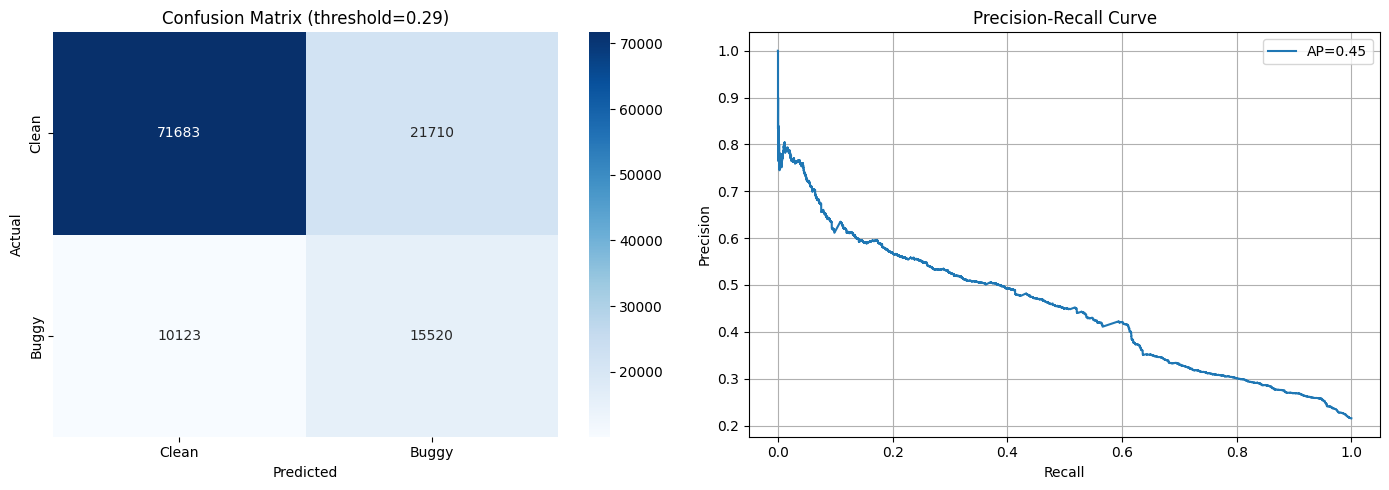

/tmp/ipykernel_1579/2036042269.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val_scaled, feature_names=FEATURE_NAMES, plot_type='bar', show=False)


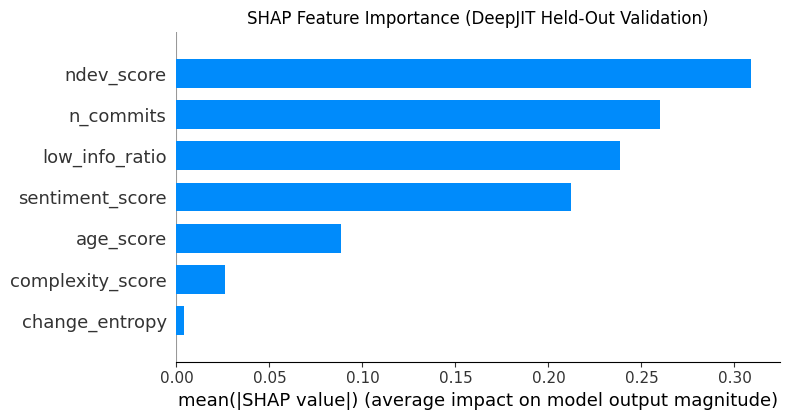

In [28]:
# ── 16. Visualizations ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score

# Confusion matrix
cm = confusion_matrix(y_val_dj, y_pred_opt)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Clean', 'Buggy'], yticklabels=['Clean', 'Buggy'])
axes[0].set_title(f'Confusion Matrix (threshold={best_thresh:.2f})')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_val_dj, y_scores)
ap = average_precision_score(y_val_dj, y_scores)
axes[1].plot(recall, precision, label=f'AP={ap:.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

# SHAP feature importance
masker = shap.maskers.Independent(X_train_scaled, max_samples=100)
explainer = shap.LinearExplainer(risk_model, masker)
shap_values = explainer.shap_values(X_val_scaled)
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_val_scaled, feature_names=FEATURE_NAMES, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (DeepJIT Held-Out Validation)')
plt.tight_layout(); plt.show()